
LAB 8: Predict diabetes (yes/no) from health measurements â€“ Pima Indians dataset

Step 1 â€” Load & Explore

--2026-06-17 09:12:45--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: â€˜diabetes.csvâ€™

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.006s  

2026-06-17 09:12:46 (4.11 MB/s) - â€˜diabetes.csvâ€™ saved [23873/23873]

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.0

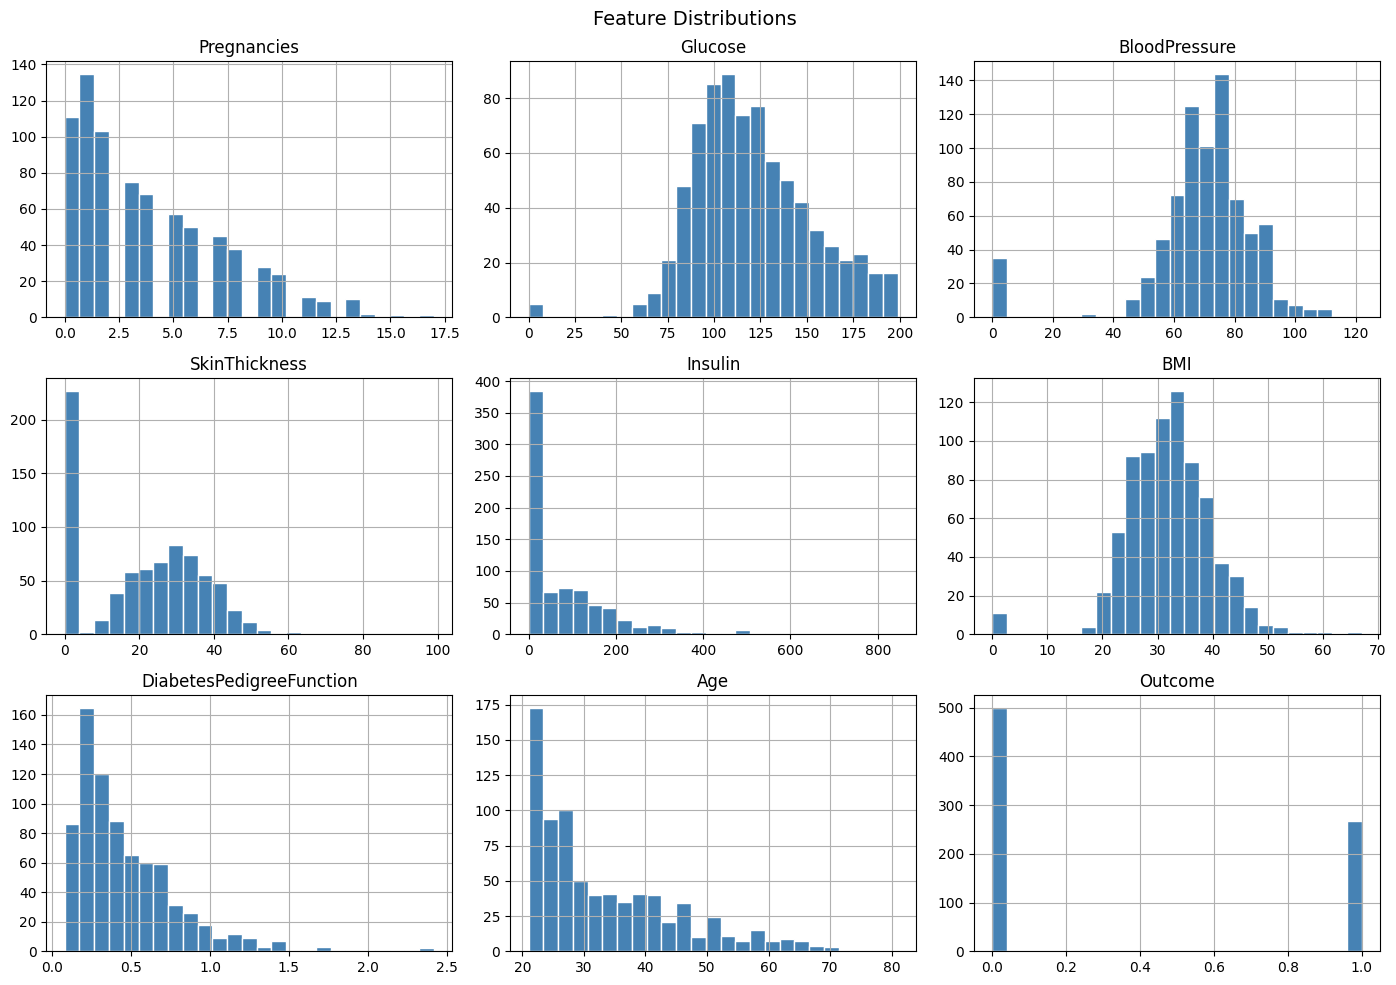

In [2]:
# â– â–  Load and Explore â– â– 
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Download the dataset if not already present
!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv') # https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
print(df.shape) # (768, 9)
print(df['Outcome'].value_counts()) # 500 healthy, 268 diabetic
print(df.describe().round(2)) # stats: mean/std/min/max
# Distribution of each feature vs outcome
df.hist(bins=25, figsize=(14,10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()

Step 2 â€” Clean (Replace Impossible Zeros)

In [3]:
# â– â–  Handle Missing Values â– â– 
# Glucose, BMI, etc. cannot be 0 â€” these are missing values disguised as zeros
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros â†’ replaced with median {df[col].median():.1f}')

Glucose                  : 5 zeros â†’ replaced with median 117.0
BloodPressure            : 35 zeros â†’ replaced with median 72.0
SkinThickness            : 227 zeros â†’ replaced with median 23.0
Insulin                  : 374 zeros â†’ replaced with median 31.2
BMI                      : 11 zeros â†’ replaced with median 32.0


Step 3 â€” Split, Scale, Train

In [4]:
# â– â–  Split, Scale, Train â– â– 
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y # stratify keeps class ratio
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit on train, transform train
X_test = scaler.transform(X_test) # only transform test (no leakage!)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Print learned coefficient for each feature
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}') # positive â†’ increases diabetes risk

Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138


Step 4 â€” Evaluate: Accuracy, Confusion Matrix, ROC

              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



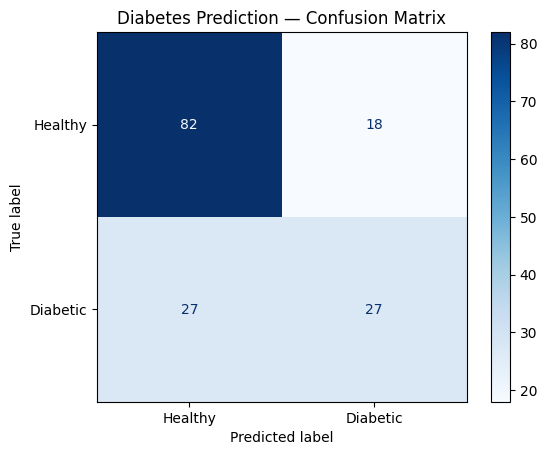

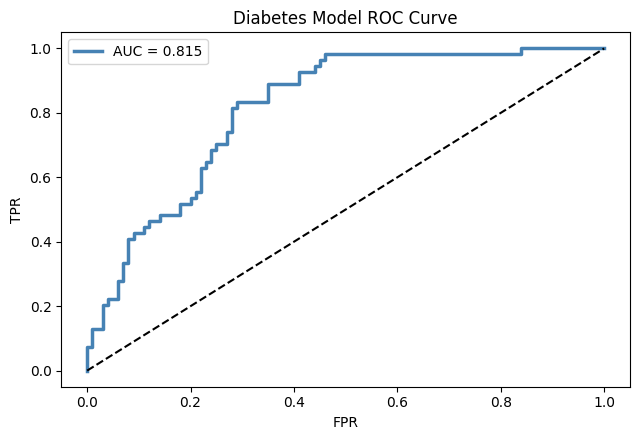

In [5]:
# â– â–  Evaluate â– â– 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction â€” Confusion Matrix'); plt.show()
# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6.5, 4.5))
plt.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()
# Expected: Accuracy ~78%, AUC ~0.84

Step 5 â€” Predict for a New Patient

Prediction : Diabetic
Probability : 73.4% chance of having diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


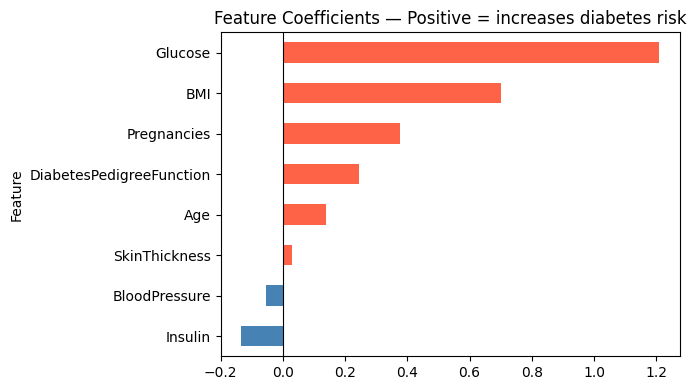

In [7]:
new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_scaled = scaler.transform(new_patient) # must use same scaler
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')
# BONUS: Plot coefficients as a horizontal bar chart
import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(7, 4))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients â€” Positive = increases diabetes risk')
plt.tight_layout(); plt.show()